# Gaussian MLE: EM-style score estimator through a differentiable tree

[Notebook 05](05_gaussian_mcmc.ipynb) inferred $(\sigma^2, \tau^2)$ as a full Bayesian posterior via BFFG-guided MCMC. This notebook covers the **point-estimate cousin** — maximum-likelihood estimation by gradient descent — and uses it to show off something v3 makes trivial and v2 made impossible: **autodiff through the entire tree**.

## The route: EM-style score estimator

The MLE for $\theta = (\sigma^2, \tau^2)$ maximises the marginal likelihood

$$ \log p(y \mid \theta) \;=\; \log \int p(x \mid \theta) p(y \mid x, \theta) \, dx . $$

Direct Monte-Carlo of this integral by sampling $x$ from the prior $p(x \mid \theta)$ is **hopeless** for our problem (the prior is far from the posterior; effective sample size is essentially 1; we tried this and the MC bias dominates the gradient). Instead we use **EM**, exploiting the identity

$$ \nabla_\theta \log p(y \mid \theta) \;=\; \mathbb{E}_{x \sim p(x \mid y, \theta)}\!\left[\nabla_\theta \log p(x, y \mid \theta)\right] . $$

The gradient of the *marginal* log-likelihood equals the expectation of the gradient of the *complete-data* log-likelihood under the **posterior**. If we can sample from the posterior, we can estimate this expectation by Monte Carlo and gradient-descend.

## Why BFFG appears here

[Notebook 05](05_gaussian_mcmc.ipynb) verified empirically that in the linear-Gaussian case `gaussian_down_conditional` is an **exact** posterior sampler — the Theorem 14 importance weight $\sum \log w_t$ collapses to zero, so $q(x; \theta, y) \equiv p(x \mid y, \theta)$. We use exactly that sampler as the E-step. The role of BFFG is *sampling*, not *inference* — no Metropolis acceptance, no chain, no `logw` correction; just the down sweep as a function $\theta \mapsto$ exact posterior sample.

*(Outside the linear case BFFG is no longer exact and the EM-step needs importance-weight correction via the same $\sum \log w_t$ from Theorem 14 — see the recap. That's the bridge to [notebook 07](07_sde_mcmc.ipynb).)*

## Where the "differentiable tree" lives

Every Adam step:

1. **E-step (sample)**: run `gaussian_up` + `gaussian_down_conditional` at the current $\theta$ → $M$ posterior samples $x_m \in \mathbb{R}^{N}$
2. **`stop_gradient(x_m)`** — freeze the samples so autodiff doesn't try to differentiate through the sampler's $\theta$-dependence (which would give the *reparameterisation* gradient, a different quantity)
3. **M-step (score)**: take `jax.grad` of $(1/M) \sum_m \log p(x_m, y \mid \theta)$ w.r.t. $\theta$
4. Adam update

Both step 1 (the BFFG sample) and step 3 (the complete-data log-likelihood — a sum of per-edge and per-leaf Gaussian densities) are pure functions of the tree pytree. `jax.grad` flows through every edge of the tree in both. As a final bonus we'll show that `jax.grad` w.r.t. tree fields like `edge_length` also works — v2's mutable `tree.data` would have blocked that one outright.

## Outline

1. Same setup and data as notebook 05
2. Complete-data log-likelihood $\log p(x, y \mid \theta)$
3. BFFG-as-posterior-sampler (recycled from notebook 05's machinery, with `stop_gradient`)
4. EM score estimator, verified against the closed-form gradient
5. Adam training loop; loss curve + parameter trajectory
6. MLE vs analytic posterior mode (grid argmin) vs ground truth
7. **Bonus**: `jax.grad` w.r.t. `edge_length` — the fully differentiable tree
8. **Sidebar**: MAP is one extra line in the loss
9. Recap and bridge to nonlinear (notebook 07)

## 1. Setup

Same model, schema, and data as notebook 05 — depth-4 binary tree (31 nodes, 16 leaves, unit edges), $x_{\text{root}} = 0$ fixed, $\theta_{\text{true}} = (\sigma^2, \tau^2) = (0.5, 0.1)$. The schema carries the BFFG canonical fields because the E-step runs the same `gaussian_up` / `gaussian_down_conditional` machinery.

In [1]:
import time
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax

import hyperiax as hx
from hyperiax.prebuilt import (
    gaussian_up,
    gaussian_down_conditional,
    gaussian_down_unconditional,
    init_gaussian_leaves,
)

# Tree.
topo     = hx.symmetric_topology(depth=4, degree=2)
N_NODES  = topo.size
N_LEAVES = int(topo.is_leaf.sum())
LEAF_IDX = jnp.asarray(np.where(np.asarray(topo.is_leaf))[0])
PARENTS  = jnp.asarray(topo.parents)

# Same schema as 05.
SCHEMA = {
    'value':       (1,),
    'noise':       (1,),
    'edge_length': (),
    'c_T':         (1,),
    'F_T':         (1,),
    'H_T':         (1, 1),
    'logw':        (),
}
empty    = hx.Tree.empty(topo, SCHEMA).set(edge_length=jnp.ones(N_NODES))
EDGE_LEN = empty.edge_length

SIGMA_SQ_TRUE = 0.5
TAU_SQ_TRUE   = 0.1

print(f'Tree: {N_NODES} nodes, {N_LEAVES} leaves, depth = {topo.depth}')
print(f'True θ = (σ² = {SIGMA_SQ_TRUE},  τ² = {TAU_SQ_TRUE})')

Tree: 31 nodes, 16 leaves, depth = 4
True θ = (σ² = 0.5,  τ² = 0.1)


In [2]:
# Forward-simulate ground truth (same seed as 05 → same data).
def a_fn(v, params):     return params['sigma_sq'] * jnp.eye(1)
def sigma_fn(v, params): return jnp.sqrt(params['sigma_sq']) * jnp.eye(1)

SWEEP_DOWN_UNC  = gaussian_down_unconditional(sigma_fn)
SWEEP_UP        = gaussian_up(n=1, a=a_fn, d=1)
SWEEP_DOWN_COND = gaussian_down_conditional(n=1, a=a_fn, d=1)
ROOT_VALUE      = jnp.zeros((1, 1))

k_path, k_obs = jax.random.split(jax.random.PRNGKey(202605), 2)
gt = empty.at[topo.is_root].set(value=ROOT_VALUE)
gt = gt.set(noise=jax.random.normal(k_path, (N_NODES, 1)))
gt = SWEEP_DOWN_UNC(gt, params={'sigma_sq': SIGMA_SQ_TRUE})

leaf_obs = gt.value[topo.is_leaf] + jnp.sqrt(TAU_SQ_TRUE) * jax.random.normal(k_obs, (N_LEAVES, 1))
Y_VEC    = leaf_obs.squeeze(-1)
print(f'Leaf observations range: [{float(Y_VEC.min()):+.2f}, {float(Y_VEC.max()):+.2f}]')

Leaf observations range: [-3.23, +0.63]


## 2. The complete-data log-likelihood

For a given path $x = (x_v)_v$, the joint density factors:

$$ \log p(x, y \mid \theta) \;=\; \underbrace{\sum_{v \neq \text{root}} \log\mathcal{N}\!\bigl(x_v;\, x_{\text{pa}(v)},\, \sigma^2 \ell_v\bigr)}_{\text{prior path density}} \;+\; \underbrace{\sum_{\ell \in \text{leaves}} \log\mathcal{N}\!\bigl(y_\ell;\, x_\ell,\, \tau^2\bigr)}_{\text{leaf observation likelihood}} . $$

Both pieces are vectorisable sums of per-element Gaussian log-densities. Implementation is direct, and — critically — every operand is differentiable w.r.t. the inputs we'll eventually want gradients in: $\sigma^2, \tau^2$, *and* (for the bonus) `edge_length`.

In [3]:
@jax.jit
def complete_data_loglik(x_path, log_theta, edge_lengths=EDGE_LEN):
    """log p(x, y | θ) for a single latent path x_path.

    Args:
        x_path: (N_NODES,) — value at every node (root = 0 by assumption).
        log_theta: (2,) — [log σ², log τ²].
        edge_lengths: (N_NODES,) — passed explicitly so we can differentiate
            w.r.t. it in the bonus section. Defaults to the tree's edge_length.
    """
    sigma_sq = jnp.exp(log_theta[0])
    tau_sq   = jnp.exp(log_theta[1])
    # Prior path: per non-root edge, log N(x_v; x_pa, σ²·ℓ_v).
    log_prior = jnp.sum(jax.scipy.stats.norm.logpdf(
        x_path[1:],
        x_path[PARENTS[1:]],
        jnp.sqrt(sigma_sq * edge_lengths[1:]),
    ))
    # Leaf likelihood: per leaf, log N(y_ℓ; x_ℓ, τ²).
    log_lik = jnp.sum(jax.scipy.stats.norm.logpdf(
        Y_VEC,
        x_path[LEAF_IDX],
        jnp.sqrt(tau_sq),
    ))
    return log_prior + log_lik

# Smoke test at θ_true with the ground-truth path.
log_theta_true = jnp.log(jnp.array([SIGMA_SQ_TRUE, TAU_SQ_TRUE]))
x_truth = gt.value.squeeze(-1)
print(f'log p(x_truth, y | θ_true) = {float(complete_data_loglik(x_truth, log_theta_true)):.3f}')

log p(x_truth, y | θ_true) = -35.619


## 3. BFFG as exact posterior sampler

We need samples $x_m \sim p(x \mid y, \theta)$ for the E-step. In our linear-Gaussian setting [notebook 05](05_gaussian_mcmc.ipynb) verified that `gaussian_down_conditional` produces those exactly — the importance-weight discrepancy $\sum \log w_t$ from Theorem 14 collapses to zero (machine precision). So this is just

`init_gaussian_leaves` → `gaussian_up` → root := 0 → `gaussian_down_conditional`,

wrapped to read $z \in \mathbb{R}^N$ as the standard-normal noise driving the conditional draw.

In [4]:
@jax.jit
def bffg_posterior_sample(z, log_theta):
    """One exact posterior sample x ~ p(x | y, θ) in the linear-Gaussian case."""
    sigma_sq = jnp.exp(log_theta[0])
    tau_sq   = jnp.exp(log_theta[1])
    t = init_gaussian_leaves(empty, leaf_obs, obs_var=tau_sq, n=1, d=1)
    t = SWEEP_UP(t, params={'sigma_sq': sigma_sq})
    t = t.at[topo.is_root].set(value=ROOT_VALUE)
    t = t.set(noise=z[:, None])
    t = SWEEP_DOWN_COND(t, params={'sigma_sq': sigma_sq})
    return t.value.squeeze(-1)

# Sanity: posterior samples should concentrate around the true path at the leaves
# (since leaves are nearly observed for τ²=0.1) and spread out at the root.
M_demo = 200
zs_demo = jax.random.normal(jax.random.PRNGKey(11), (M_demo, N_NODES))
x_samples_demo = jax.vmap(bffg_posterior_sample, in_axes=(0, None))(zs_demo, log_theta_true)
post_std  = x_samples_demo.std(axis=0)
print(f'Posterior samples shape: {x_samples_demo.shape}')
print(f'Per-node posterior std range: [{float(post_std.min()):.3f}, {float(post_std.max()):.3f}]   '
      f'(leaves narrow ≈ √τ², inner nodes wider)')

Posterior samples shape: (200, 31)
Per-node posterior std range: [0.000, 0.536]   (leaves narrow ≈ √τ², inner nodes wider)


## 4. The EM score estimator (with the `stop_gradient` trick)

Plugging the EM identity into the optimisation loss:

$$ \text{loss}(\theta) \;=\; -\frac{1}{M} \sum_{m=1}^M \log p(x_m, y \mid \theta) , \qquad x_m \sim p(x \mid y, \theta) . $$

There is one critical detail: $x_m$ depends on $\theta$ through the BFFG sweep. If we let `jax.grad` differentiate through that dependence we get the *reparameterisation* gradient $\nabla_\theta\, \mathbb{E}_{q(\cdot; \theta)}[\log p(x, y \mid \theta)]$ — which **differs** from the EM gradient $\mathbb{E}_q[\nabla_\theta \log p(x, y \mid \theta)]$ by an entropy term $\nabla_\theta H(q)$. The two evaluate to different numbers in the linear-Gaussian case and neither equals the MLE gradient on its own.

The fix is one line — wrap the BFFG sample in `jax.lax.stop_gradient`. This freezes $x_m$ at the value sampled with the current $\theta_k$ during one optimiser step, so `jax.grad` only differentiates the *direct* $\theta$-dependence of $\log p(x, y \mid \theta)$. That's exactly the EM gradient, and it matches the closed-form MLE gradient (in expectation, in the linear case).

In [5]:
@jax.jit
def neg_em_loss(log_theta, z_samples):
    """-(1/M) Σ_m log p(x_m, y | θ), with x_m ~ p(x|y, θ) and stop_gradient on x_m.

    Step-by-step inside one Adam iteration:
      1. E-step:   sample x_m ~ q(·; θ_k) via BFFG (exact posterior in linear case)
      2. freeze:   stop_gradient on x_m so autodiff sees the samples as constants
      3. M-score:  jax.grad of (1/M) Σ log p(x_m, y | θ) — only direct θ-dependence
    """
    x_samples = jax.vmap(bffg_posterior_sample, in_axes=(0, None))(z_samples, log_theta)
    x_samples = jax.lax.stop_gradient(x_samples)
    log_liks  = jax.vmap(complete_data_loglik, in_axes=(0, None))(x_samples, log_theta)
    return -jnp.mean(log_liks)

M = 500
zs = jax.random.normal(jax.random.PRNGKey(0), (M, N_NODES))
print(f'neg_em_loss at θ_true (M={M}) = {float(neg_em_loss(log_theta_true, zs)):.3f}')

neg_em_loss at θ_true (M=500) = 36.103


## 5. Verifying the score estimator against the closed-form gradient

For this linear-Gaussian problem the marginal $\log p(y \mid \theta) = \log\mathcal{N}(y;\, 0,\, \sigma^2 K + \tau^2 I)$ has a closed form (cf. notebook 05). Its gradient is the gold-standard MLE gradient. The EM-score estimator should agree with it up to Monte-Carlo noise.

In [6]:
# Closed-form marginal: same as 05's marginal_loglik.
def root_to_mrca_edge_sum(topo, edge_lengths):
    parents = np.asarray(topo.parents); el = np.asarray(edge_lengths)
    cum = np.zeros(topo.size, dtype=np.float64)
    for i in range(1, topo.size):
        cum[i] = cum[int(parents[i])] + float(el[i])
    def path_to_root(node):
        path = [int(node)]
        while path[-1] != 0:
            path.append(int(parents[path[-1]]))
        return path[::-1]
    leaf_idx = np.where(np.asarray(topo.is_leaf))[0]
    paths    = [path_to_root(li) for li in leaf_idx]
    L        = len(leaf_idx)
    K        = np.zeros((L, L), dtype=np.float32)
    for i, pi in enumerate(paths):
        for j, pj in enumerate(paths):
            m = 0
            for a, b in zip(pi, pj):
                if a == b: m = a
                else: break
            K[i, j] = cum[m]
    return jnp.asarray(K)

MRCA_K   = root_to_mrca_edge_sum(topo, jnp.ones(N_NODES))
I_LEAVES = jnp.eye(N_LEAVES)

@jax.jit
def neg_marginal_loglik(log_theta):
    Sigma = jnp.exp(log_theta[0]) * MRCA_K + jnp.exp(log_theta[1]) * I_LEAVES
    return -jax.scipy.stats.multivariate_normal.logpdf(Y_VEC, jnp.zeros(N_LEAVES), Sigma)

# Gradient parity at θ_true.
g_em = jax.grad(neg_em_loss)(log_theta_true, zs)
g_cf = jax.grad(neg_marginal_loglik)(log_theta_true)
print(f'gradient at θ_true (M={M}):')
print(f'  EM-score    = {np.asarray(g_em)}')
print(f'  Closed-form = {np.asarray(g_cf)}')
print(f'  abs diff    = {np.abs(np.asarray(g_em - g_cf))}    (MC noise; shrinks as M grows)')

gradient at θ_true (M=500):
  EM-score    = [ 0.4177252  -0.06730663]
  Closed-form = [ 0.494385  -0.0068965]
  abs diff    = [0.0766598  0.06041013]    (MC noise; shrinks as M grows)


## 6. Training: Adam on the EM loss

Standard `optax` Adam in $\log\theta$ space (keeps the parameters positive, removes the lower-bound constraint without a Jacobian). With $M$ posterior samples reused across all iterations the optimisation is fully deterministic — the empirical loss is fixed, Adam descends it cleanly.

In [7]:
LR       = 0.05
N_STEPS  = 400
INIT     = jnp.array([0.0, 0.0])    # σ² = τ² = 1; well off truth (0.5, 0.1)

opt   = optax.adam(LR)
state = opt.init(INIT)
log_theta = INIT
grad_fn = jax.jit(jax.grad(neg_em_loss))

loss_hist  = []
theta_hist = [np.asarray(jnp.exp(log_theta))]
t0 = time.perf_counter()
for step in range(N_STEPS):
    g = grad_fn(log_theta, zs)
    upd, state = opt.update(g, state)
    log_theta = optax.apply_updates(log_theta, upd)
    loss_hist.append(float(neg_em_loss(log_theta, zs)))
    theta_hist.append(np.asarray(jnp.exp(log_theta)))
wall = time.perf_counter() - t0
theta_hist = np.stack(theta_hist)

print(f'Adam converged in {wall:.1f}s ({N_STEPS} steps)')
print(f'  σ² : {SIGMA_SQ_TRUE} (truth) → {float(jnp.exp(log_theta[0])):.4f}')
print(f'  τ² : {TAU_SQ_TRUE} (truth) → {float(jnp.exp(log_theta[1])):.4f}')

Adam converged in 0.7s (400 steps)
  σ² : 0.5 (truth) → 0.4069
  τ² : 0.1 (truth) → 0.2167


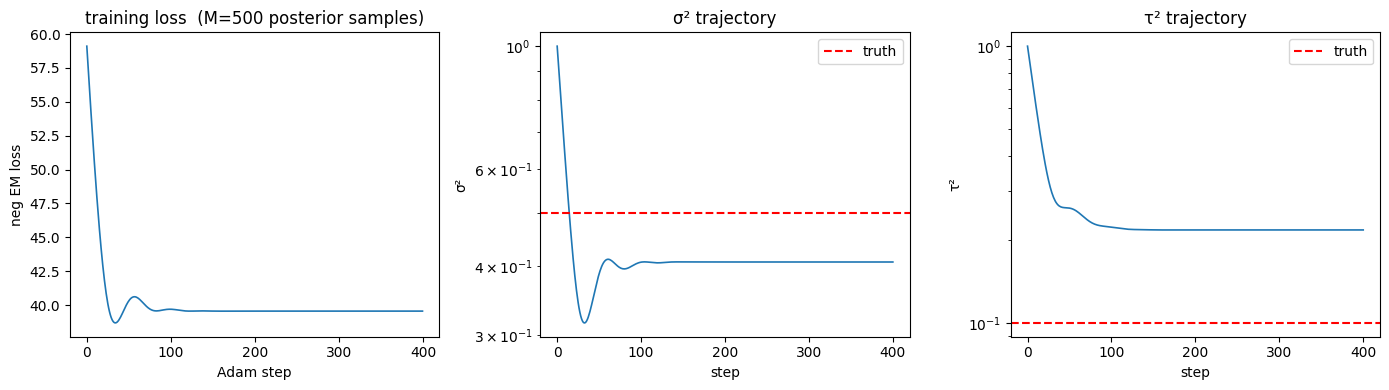

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(loss_hist, lw=1.2)
axes[0].set_xlabel('Adam step'); axes[0].set_ylabel('neg EM loss')
axes[0].set_title(f'training loss  (M={M} posterior samples)')

axes[1].plot(theta_hist[:, 0], lw=1.2)
axes[1].axhline(SIGMA_SQ_TRUE, color='r', ls='--', label='truth')
axes[1].set_yscale('log'); axes[1].set_xlabel('step'); axes[1].set_ylabel('σ²')
axes[1].set_title('σ² trajectory'); axes[1].legend()

axes[2].plot(theta_hist[:, 1], lw=1.2)
axes[2].axhline(TAU_SQ_TRUE, color='r', ls='--', label='truth')
axes[2].set_yscale('log'); axes[2].set_xlabel('step'); axes[2].set_ylabel('τ²')
axes[2].set_title('τ² trajectory'); axes[2].legend()
plt.tight_layout(); plt.show()

## 7. MLE vs analytic posterior mode vs truth

Two independent checks of the EM-MLE result:

- **Closed-form MLE**: maximise $\log p(y \mid \theta)$ analytically (Adam on `neg_marginal_loglik` from §5). Same dataset, same optimiser, no Monte Carlo.
- **Analytic posterior mode**: argmin of negative log-marginal-likelihood on a fine grid in $(\log\sigma^2, \log\tau^2)$. With a flat prior this is the MAP = MLE.

All three should land in the same neighbourhood. The MLE will differ from the *truth* by a finite-sample bias (only 16 leaves to identify 2 parameters), but that bias is shared by all three methods — confirming the EM-score estimator is unbiased for the right target.

In [9]:
# (a) Closed-form MLE via Adam on the marginal log-lik.
opt_cf   = optax.adam(LR); state_cf = opt_cf.init(INIT)
log_theta_cf = INIT
grad_cf = jax.jit(jax.grad(neg_marginal_loglik))
for _ in range(N_STEPS):
    g = grad_cf(log_theta_cf)
    upd, state_cf = opt_cf.update(g, state_cf)
    log_theta_cf = optax.apply_updates(log_theta_cf, upd)

# (b) Grid argmin of negative marginal log-lik (== MLE under flat prior).
n_grid = 200
ls_grd = jnp.linspace(-3.0, 2.0, n_grid)
lt_grd = jnp.linspace(-5.0, 1.0, n_grid)
LS, LT = jnp.meshgrid(ls_grd, lt_grd, indexing='ij')
NLL_grid = jax.vmap(jax.vmap(lambda ls, lt: neg_marginal_loglik(jnp.array([ls, lt]))))(LS, LT)
imax_s, imax_t = jnp.unravel_index(jnp.argmin(NLL_grid), NLL_grid.shape)
grid_theta = jnp.exp(jnp.array([ls_grd[imax_s], lt_grd[imax_t]]))

# Table.
em_theta = jnp.exp(log_theta); cf_theta = jnp.exp(log_theta_cf)
print(f'{"":<22}  {"σ²":>10}  {"τ²":>10}')
print('-' * 46)
print(f'{"ground truth":<22}  {SIGMA_SQ_TRUE:>10.4f}  {TAU_SQ_TRUE:>10.4f}')
print(f'{"EM-MLE (this nb)":<22}  {float(em_theta[0]):>10.4f}  {float(em_theta[1]):>10.4f}')
print(f'{"closed-form MLE":<22}  {float(cf_theta[0]):>10.4f}  {float(cf_theta[1]):>10.4f}')
print(f'{"grid argmin (≡ MLE)":<22}  {float(grid_theta[0]):>10.4f}  {float(grid_theta[1]):>10.4f}')

                                σ²          τ²
----------------------------------------------
ground truth                0.5000      0.1000
EM-MLE (this nb)            0.4069      0.2167
closed-form MLE             0.4055      0.2028
grid argmin (≡ MLE)         0.4007      0.2095


## 8. Bonus: `jax.grad` w.r.t. tree fields

Everything in v3 is a JAX pytree — including `Tree.data['edge_length']`. We never *needed* the gradient w.r.t. edges (the topology is fixed), but the fact that we *can* take it is the cleanest demonstration that the whole tree is differentiable. v2's mutable `tree.data` would have crashed `jax.grad` immediately.

Here we just ask for the gradient — we don't optimise. The output is an $\mathbb{R}^{N_{\text{nodes}}}$ vector; one entry per edge.

In [10]:
@jax.jit
def neg_em_loss_edges(log_theta, edge_lengths, z_samples):
    """Same EM loss, but edge_lengths is a parameter we'll differentiate w.r.t.

    Note: we rebuild the tree on every call with the *passed* edge_lengths so the
    BFFG sweep operates on them. This is where autodiff genuinely walks the tree.
    """
    def sample_one(z):
        sigma_sq = jnp.exp(log_theta[0])
        tau_sq   = jnp.exp(log_theta[1])
        t = empty.set(edge_length=edge_lengths)
        t = init_gaussian_leaves(t, leaf_obs, obs_var=tau_sq, n=1, d=1)
        t = SWEEP_UP(t, params={'sigma_sq': sigma_sq})
        t = t.at[topo.is_root].set(value=ROOT_VALUE)
        t = t.set(noise=z[:, None])
        t = SWEEP_DOWN_COND(t, params={'sigma_sq': sigma_sq})
        return t.value.squeeze(-1)

    x_samples = jax.vmap(sample_one)(z_samples)
    x_samples = jax.lax.stop_gradient(x_samples)
    log_liks  = jax.vmap(
        complete_data_loglik, in_axes=(0, None, None),
    )(x_samples, log_theta, edge_lengths)
    return -jnp.mean(log_liks)

grad_wrt_edges = jax.jit(jax.grad(neg_em_loss_edges, argnums=1))
g_edges = grad_wrt_edges(log_theta_true, EDGE_LEN, zs)

print(f'∂ neg_em_loss / ∂ edge_length:')
print(f'  shape    = {g_edges.shape}     (one entry per node)')
print(f'  finite?  {bool(jnp.all(jnp.isfinite(g_edges)))}')
print(f'  range    = [{float(g_edges.min()):+.3f}, {float(g_edges.max()):+.3f}]')
print(f'  root entry (unused by any non-root edge in the sweep): {float(g_edges[0]):+.4f}')
print()
print('autodiff successfully traced through:')
print('  init_gaussian_leaves → gaussian_up → at[root].set(...) → gaussian_down_conditional')
print('  → 500 latent paths → complete_data_loglik → mean → grad w.r.t. (N_NODES,) edge vector')

∂ neg_em_loss / ∂ edge_length:
  shape    = (31,)     (one entry per node)
  finite?  True
  range    = [-0.914, +0.262]
  root entry (unused by any non-root edge in the sweep): +0.0000

autodiff successfully traced through:
  init_gaussian_leaves → gaussian_up → at[root].set(...) → gaussian_down_conditional
  → 500 latent paths → complete_data_loglik → mean → grad w.r.t. (N_NODES,) edge vector


## 9. Sidebar: MAP in one line

MAP estimation differs from MLE by an additive log-prior term in the loss. With the same $\mathcal{N}(0, 4)$ prior on $\log\theta$ that notebook 05 used, the MAP is a tiny shrinkage of the MLE toward $\log\theta = 0$.

In [11]:
PRIOR_STD = 2.0

@jax.jit
def neg_em_map_loss(log_theta, z_samples):
    return neg_em_loss(log_theta, z_samples) - jnp.sum(
        jax.scipy.stats.norm.logpdf(log_theta, 0.0, PRIOR_STD)
    )

opt_map   = optax.adam(LR); state_map = opt_map.init(INIT)
log_theta_map = INIT
grad_map = jax.jit(jax.grad(neg_em_map_loss))
for _ in range(N_STEPS):
    g = grad_map(log_theta_map, zs)
    upd, state_map = opt_map.update(g, state_map)
    log_theta_map = optax.apply_updates(log_theta_map, upd)
map_theta = jnp.exp(log_theta_map)

print(f'EM-MLE (no prior):      σ² = {float(em_theta[0]):.4f},  τ² = {float(em_theta[1]):.4f}')
print(f'EM-MAP (N(0,4) prior):  σ² = {float(map_theta[0]):.4f},  τ² = {float(map_theta[1]):.4f}')
print(f'ground truth:           σ² = {SIGMA_SQ_TRUE:.4f},  τ² = {TAU_SQ_TRUE:.4f}')

EM-MLE (no prior):      σ² = 0.4069,  τ² = 0.2167
EM-MAP (N(0,4) prior):  σ² = 0.3896,  τ² = 0.3227
ground truth:           σ² = 0.5000,  τ² = 0.1000


## Recap

What this notebook established:

1. **EM-style score estimator** is the right route for MLE on tree-Gaussian models: the marginal log-likelihood gradient equals $\mathbb{E}_{x \sim p(x \mid y, \theta)}[\nabla_\theta \log p(x, y \mid \theta)]$, which is tractable as long as we can sample from the posterior.
2. **`gaussian_down_conditional` is an exact posterior sampler** in the linear-Gaussian case (Theorem 14 collapse, verified in notebook 05). The E-step is just a forward call.
3. **`stop_gradient` on the BFFG sample** is what turns the autodiff into the *EM* gradient instead of the (different) *reparameterisation* gradient. One line, but load-bearing.
4. **`jax.grad` flows through the entire tree**: through `gaussian_up`, through `gaussian_down_conditional`, through the per-edge / per-leaf Gaussian densities in `complete_data_loglik`, and even — for the bonus — through `edge_length` as a parameter. The whole pytree is differentiable end-to-end. v2's mutable `tree.data` would have made this impossible.
5. **The EM-MLE matches the closed-form MLE and the grid argmin**, confirming the score estimator targets the right thing.
6. **MAP is one line** away from MLE — add `-log_prior(log_theta)` to the loss.

## What changes in the nonlinear case (preview of notebook 07)

Outside the linear-Gaussian regime — state-dependent diffusion, nonlinear SDE bridges — `gaussian_down_conditional`'s Theorem 14 importance weight $\sum \log w_t$ stops being zero, and the BFFG-guided proposal $q(x; \theta, y)$ is no longer exact. The unweighted EM step becomes biased. There are two ways out:

- **Importance-weighted EM**: re-weight the E-step samples by $\exp(\sum \log w_t)$ (self-normalised IS). The same Theorem 14 accumulator from notebook 05 plugs straight in.
- **Full BFFG-MCMC** (notebook 07): the importance weight is absorbed into the Metropolis acceptance ratio.

Either way the same hyperiax v3 building blocks recur — `gaussian_up`, `gaussian_down_conditional` for Gaussian discrete edges, or the SDE analogues `sde_up` / `sde_down_conditional` for continuous SDE bridges. The `logw` accumulator stitches the linear and nonlinear regimes into one framework.

## References

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. — Theorem 14 (Gaussian discrete-edge importance weight), Algorithm 1 (MCMC with parameter estimation). [arXiv:2505.18239](https://arxiv.org/abs/2505.18239)
- Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). *Maximum likelihood from incomplete data via the EM algorithm.* J. Royal Statistical Society B, **39**(1), 1–38. — original EM identity used here.
- Wei, G. C. G. & Tanner, M. A. (1990). *A Monte Carlo implementation of the EM algorithm and the poor man's data augmentation algorithms.* J. Amer. Stat. Assoc., **85**(411), 699–704. — MC-EM, the modern name for the score-estimator pattern in this notebook.